In [10]:
import torch
import torch.nn.functional as F
from torchvision import transforms
import cv2
import torchvision.io as io
import numpy as np
import matplotlib.pyplot as plt

In [14]:
cap = cv2.VideoCapture("walrus.mp4")
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 
    frames.append(gray)

cap.release()

video_np = np.array(frames)  # shape = (N, H, W)
print(video_np.shape)

(457, 1920, 1080, 3)


Text(0.5, 1.0, 'raw image frame 0')

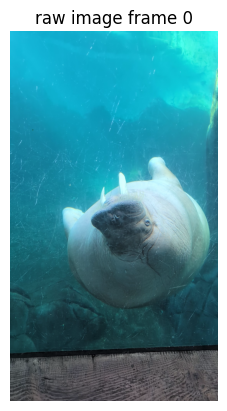

In [15]:
N = video_np.shape[0]
indices = [int(i * N / 9) for i in range(9)]
frames_9 = video_np[indices]  # (9, H, W)

plt.figure()
plt.imshow(frames_9[0])
plt.axis('off')
plt.title('raw image frame 0')

In [19]:
frames_t = torch.from_numpy(frames_9).float() / 255.0  # (9, H, W, 3)
frames_t = frames_t.permute(0, 3, 1, 2)  # (9, 3, H, W)

H, W = frames_t.shape[2], frames_t.shape[3]
H_new = (H // 100) * 16
W_new = (W // 100) * 16
frames_t = F.interpolate(frames_t, size=(H_new, W_new))  # (9, 3, H_new, W_new)

frames_t = frames_t.permute(1, 0, 2, 3)  # (3, 9, H_new, W_new)
frames_t = frames_t * 2 - 1  # [-1, 1]
H_new, W_new, frames_t.shape

(304, 160, torch.Size([3, 9, 304, 160]))

In [ ]:
from vae2_2 import Wan2_2_VAE